# 03 — Model training

เทียบ 3 โมเดลที่เลือก execution mode: **if-else, Random Forest, MLP**

| โมเดล | time lost ↓ | accuracy |
|---|---|---|
| always multiprocessing (baseline) | +22.1% | 44.7% |
| if-else | +13.0% | 72.7% |
| Random Forest | +5.8% | 85.7% |
| **MLP (Optuna)** | **+4.3%** | 84.5% |

ขั้นตอน: 1. ข้อมูล → 2. แบ่ง train/test → 3. ตัววัดผล → 4. baseline → 5. if-else → 6. RF → 7. MLP → 8. stress test → 9. สรุป

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helpers import FEATURE_NAMES, MODES, TIME_COLS, COLORS, load_clean, time_lost, setup_plots, save

setup_plots()
df = load_clean()
print(df.shape)

(13603, 32)


## 1. ข้อมูล

- **X** = 13 feature, **y** = mode ที่เร็วที่สุด (ต่างกันไม่เกิน 5% ถือว่าเสมอ)
- **groups** (template) ใช้แบ่ง data เท่านั้น ส่วน **times** (เวลาจริงทั้ง 3 mode) ใช้วัดผลเท่านั้น ทั้งสองอย่างไม่ได้ใส่ใน X

In [2]:
X = df[FEATURE_NAMES]          # 13 feature ที่ตกลงกันไว้
y = df["y"]                    # คำตอบ
groups = df["template_id"]     # สำหรับแบ่ง data
times = df[TIME_COLS].to_numpy()

print("X:", X.shape, "| y:", y.shape, "| groups:", groups.nunique(), "templates")
X.head()

X: (13603, 13) | y: (13603,) | groups: 52 templates


,n_items,input_bytes,cpu_count,n_workers,max_loop_depth,arith_op_count,has_io_call,has_gil_release_call,time_per_item,cpu_ratio,time_cv,pickle_time_ratio,thread_probe_speedup
0,77,115334.0,4,4,2,15,0,0,0.000491,1.000000,0.172963,0.040336,0.809031
1,21,77.0,4,2,5,9,0,0,0.013499,1.000000,0.006971,0.003038,0.964699
2,151,1321528.0,4,4,2,5,0,0,0.001046,1.000000,0.277874,0.707966,0.863781
3,568,11567.0,4,4,0,1,1,0,0.002574,0.006739,0.460548,0.002315,1.789958
4,206,1774.0,4,4,1,10,0,0,0.000816,1.000000,0.085842,0.003809,0.966526


In [3]:
# 1) y แต่ละ class มีกี่แถว
print(y.value_counts())

# 2) แต่ละ template มีกี่แถว -> ดูตัวที่มากที่สุดกับน้อยที่สุด
rows_per_template = groups.value_counts()
print("มากที่สุด:", rows_per_template.max())
print("น้อยที่สุด:", rows_per_template.min())

y
multiprocessing    6085
sequential         4545
threading          2973
Name: count, dtype: int64
มากที่สุด: 308
น้อยที่สุด: 228


13,603 แถว จาก 52 template แต่ละ template มี 228–308 แถว ไม่มี template ไหนครอบงำ data

**ตัวอย่าง data leakage:** ถ้าใส่เวลาจริงลงใน X จะเหมือนแอบให้เฉลยกับโมเดล (ทดสอบด้วย decision tree)

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

leak = X.copy()
leak["seq_vs_mp"] = df.t_sequential / df.t_multiprocessing    # มาจากเวลาจริง = คำตอบ
leak["thr_vs_mp"] = df.t_threading / df.t_multiprocessing

tree = DecisionTreeClassifier(max_depth=5, random_state=0)
acc_a = cross_val_score(tree, X, y, cv=5).mean()
acc_b = cross_val_score(tree, leak, y, cv=5).mean()
print(f"A  13 feature                 : {acc_a:.1%}")
print(f"B  13 feature + เวลาจริง (leak) : {acc_b:.1%}")

A  13 feature                 : 83.4%
B  13 feature + เวลาจริง (leak) : 96.5%


accuracy 83% → 96% เพียงเพราะใส่คำตอบเพิ่ม 2 คอลัมน์ คะแนนที่สูงผิดปกติจึงเป็นสัญญาณของ leakage

---
## 2. แบ่ง train/test ตาม template

decorator ต้องใช้กับโค้ดที่ไม่เคยเห็น ข้อสอบจึงต้องเป็น **template ที่ไม่เคยเห็น** (StratifiedGroupKFold, 5 fold) ถ้าสุ่มแบ่งเป็นแถว โมเดลจะจำ template ได้ และคะแนนจะดูดีเกินจริง

In [5]:
from sklearn.model_selection import StratifiedGroupKFold

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
folds = list(cv.split(X, y, groups))      # 5 คู่ของ (index ของ train, index ของ test)

for k, (tr, te) in enumerate(folds, 1):
    shared = set(groups.iloc[tr]) & set(groups.iloc[te])
    print(f"fold {k}: train {len(tr):5d} rows / test {len(te):5d} rows | "
          f"test templates {groups.iloc[te].nunique():2d} | templates in both: {len(shared)}")

fold 1: train 10673 rows / test  2930 rows | test templates 11 | templates in both: 0
fold 2: train 10998 rows / test  2605 rows | test templates 10 | templates in both: 0
fold 3: train 10995 rows / test  2608 rows | test templates 10 | templates in both: 0
fold 4: train 10963 rows / test  2640 rows | test templates 10 | templates in both: 0
fold 5: train 10783 rows / test  2820 rows | test templates 11 | templates in both: 0


```
52 templates
├── outer fold ×5
│   ├── test  ~10 templates  -> เทียบโมเดล (ไม่แตะระหว่างจูน)
│   └── train ~42 templates
│       ├── validation        -> จูน hyperparameter / early stopping
│       └── train             -> fit น้ำหนัก
└── โค้ดจริง (pyperformance)  -> ทดสอบครั้งสุดท้าย (ทดสอบด้วยโค้ดจริงจาก pyperformance)
```
ภาพด้านล่าง: ช่องสีเข้ม = template ที่อยู่ใน test ของรอบนั้น

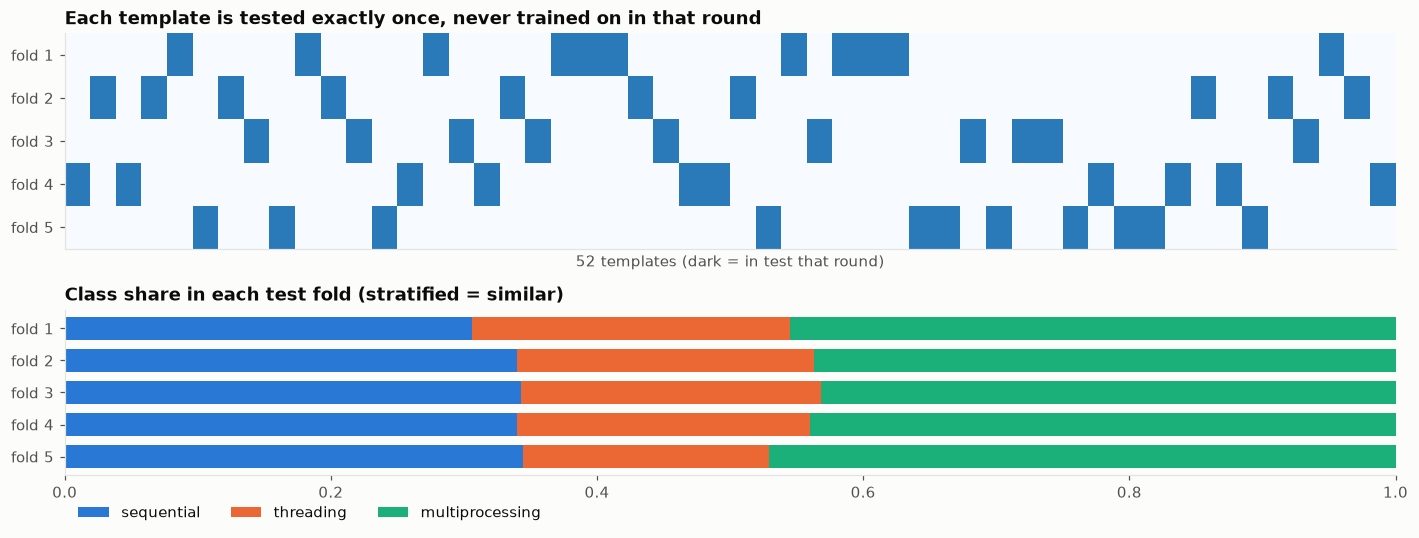

In [6]:
tmpl = sorted(groups.unique())
grid = np.zeros((len(folds), len(tmpl)))
for k, (tr, te) in enumerate(folds):
    for t in groups.iloc[te].unique():
        grid[k, tmpl.index(t)] = 1

fig, axes = plt.subplots(2, 1, figsize=(13, 5), gridspec_kw={"height_ratios": [1.3, 1]})
axes[0].imshow(grid, cmap="Blues", aspect="auto", vmin=0, vmax=1.4)
axes[0].set_yticks(range(5), [f"fold {k}" for k in range(1, 6)])
axes[0].set_xticks([]); axes[0].set_xlabel("52 templates (dark = in test that round)")
axes[0].grid(False)
axes[0].set_title("Each template is tested exactly once, never trained on in that round")

share = pd.DataFrame([y.iloc[te].value_counts(normalize=True) for _, te in folds])[MODES]
left = np.zeros(5)
for m in MODES:
    axes[1].barh(range(5), share[m], left=left, color=COLORS[m], label=m, height=0.7)
    left += share[m].to_numpy()
axes[1].set_yticks(range(5), [f"fold {k}" for k in range(1, 6)])
axes[1].set_xlim(0, 1); axes[1].grid(False); axes[1].invert_yaxis()   # fold 1 on top, like the grid above
axes[1].legend(ncol=3, frameon=False, loc="upper left", bbox_to_anchor=(0, -0.1))
axes[1].set_title("Class share in each test fold (stratified = similar)")
save(fig, "03_group_folds")
plt.show()

---
## 3. ตัววัดผล: time lost

| งาน | seq | thread | mp |
|---|---|---|---|
| A เล็ก | **0.01 s** | 0.011 s | 0.15 s |
| C ใหญ่ | 40 s | 38 s | **10 s** |

ทายผิดงาน A เสียเวลาแค่เสี้ยววินาที แต่ทายผิดงาน C เสียไป 30 s ถ้าดูแค่ accuracy จะเห็นสองกรณีนี้เท่ากัน จึงใช้:

```
time lost = (เวลารวมของ mode ที่เลือก ÷ เวลารวมถ้าเลือกถูกทุกครั้ง − 1) × 100%    (0% = สมบูรณ์แบบ)
```

In [8]:
rows = []
for mode in MODES:
    pred = np.full(len(y), mode)              # ทายเป็น mode นี้ทุกแถว
    acc = (pred == y).mean()                # สัดส่วนที่ทายถูก
    lost = time_lost(times, pred)               # เวลาที่เสียไป (%)
    rows.append({"strategy": f"always {mode}", "accuracy": acc, "time lost %": lost})

pd.DataFrame(rows).round(3)

,strategy,accuracy,time lost %
0,always sequential,0.334,84.237
1,always threading,0.219,71.491
2,always multiprocessing,0.447,22.057


ดูเฉพาะครั้งที่ทายผิดของ "always multiprocessing":

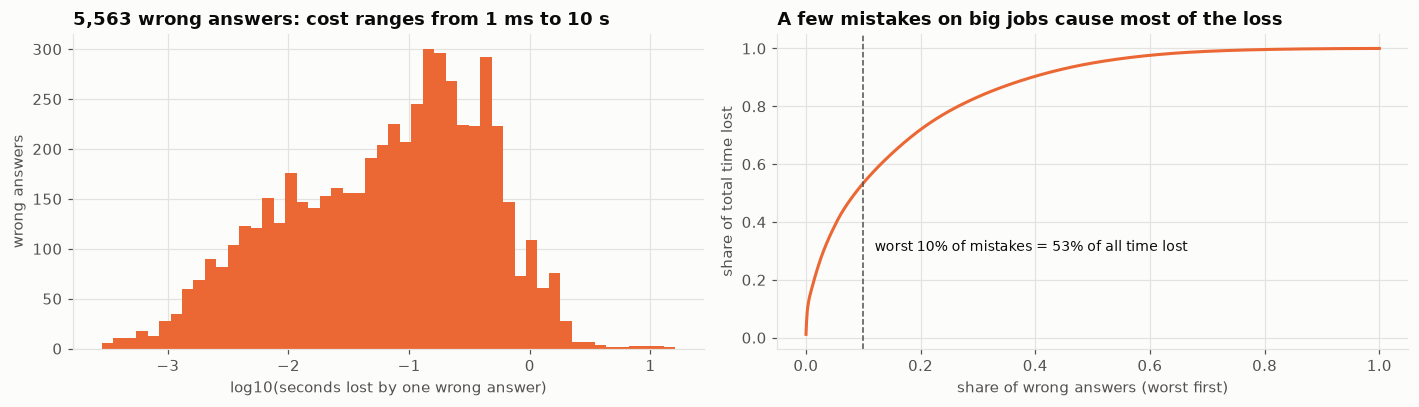

In [9]:
best = times.min(axis=1)
picked = times[:, MODES.index("multiprocessing")]
wrong = picked > best * 1.05                    # ผิดจริง (เกินกฎเสมอ 5%)
cost = (picked - best)[wrong]                   # วินาทีที่เสียต่อการทายผิด 1 ครั้ง

srt = np.sort(cost)[::-1]
share = np.cumsum(srt) / srt.sum()
top10 = int(len(srt) * 0.10)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].hist(np.log10(cost), bins=50, color=COLORS["threading"])
axes[0].set_xlabel("log10(seconds lost by one wrong answer)")
axes[0].set_ylabel("wrong answers")
axes[0].set_title(f"{wrong.sum():,} wrong answers: cost ranges from 1 ms to 10 s")
axes[1].plot(np.arange(1, len(srt) + 1) / len(srt), share, color=COLORS["threading"], lw=2)
axes[1].axvline(0.10, color="#52514e", ls="--", lw=1)
axes[1].text(0.12, 0.3, f"worst 10% of mistakes = {share[top10]:.0%} of all time lost", fontsize=9)
axes[1].set_xlabel("share of wrong answers (worst first)")
axes[1].set_ylabel("share of total time lost")
axes[1].set_title("A few mistakes on big jobs cause most of the loss")
save(fig, "03_cost_of_mistakes")
plt.show()

- always sequential ได้ accuracy สูงกว่า always threading แต่เสียเวลามากกว่า สองตัววัดจึงให้ผลสวนทางกัน
- การทายผิด 10% ที่แย่ที่สุดกินเวลาที่เสียไปราวครึ่งหนึ่ง → **เลือกโมเดลด้วย time lost**

---
## 4. Baseline: ใช้ multiprocessing ตลอด

`evaluate()` ใช้ 5 fold เดียวกันกับทุกโมเดลและบันทึกผลลง MLflow ส่วน `report()` วาดกราฟแยก fold, แยกเครื่อง และ confusion matrix

In [10]:
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, confusion_matrix
from helpers import setup_mlflow

mlflow = setup_mlflow()      # every evaluate() call becomes one MLflow run

results = {}

def evaluate(model, name, X=X):
    """Train on each train fold, predict its test fold, score the out-of-fold predictions."""
    pred = np.empty(len(y), dtype=object)
    per_fold, fitted = [], []
    for k, (tr, te) in enumerate(folds, 1):
        m = clone(model).fit(X.iloc[tr], y.iloc[tr])          # fresh copy each fold: no memory between folds
        pred[te] = m.predict(X.iloc[te])
        fitted.append(m)
        per_fold.append({"fold": k, "accuracy": (pred[te] == y.iloc[te]).mean(),
                         "time lost %": time_lost(times[te], pred[te])})
    summary = {"model": name,
               "accuracy": (pred == y).mean(),
               "macro F1": f1_score(y, pred, average="macro"),
               "time lost %": time_lost(times, pred)}
    per_fold = pd.DataFrame(per_fold)

    with mlflow.start_run(run_name=name) as run:
        params = {k: v for k, v in model.get_params().items() if np.isscalar(v) or v is None}
        mlflow.log_params({"model": name, "model_class": type(model).__name__, **params})
        mlflow.log_metrics({"accuracy": summary["accuracy"], "macro_f1": summary["macro F1"],
                            "time_lost_pct": summary["time lost %"],
                            "time_lost_pct_worst_fold": per_fold["time lost %"].max()})
        for _, row in per_fold.iterrows():
            mlflow.log_metric("time_lost_pct_fold", row["time lost %"], step=int(row["fold"]))

    results[name] = {**summary, "pred": pred, "per_fold": per_fold, "run_id": run.info.run_id, "models": fitted}
    return pd.Series(summary)


def report(name):
    """Three charts for one model: per fold, per machine, confusion matrix."""
    r = results[name]
    pred = r["pred"]
    per_machine = pd.Series({m: time_lost(times[idx], pred[idx])
                             for m, idx in df.groupby("machine_id").indices.items()})
    order = df.groupby("machine_id").cpu_count.first().sort_values(kind="stable").index

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1, 1.6, 1.1]})
    pf = r["per_fold"]
    axes[0].bar(pf.fold, pf["time lost %"], color=COLORS["multiprocessing"], width=0.6)
    axes[0].axhline(r["time lost %"], color="#52514e", ls="--", lw=1)
    axes[0].text(0.6, r["time lost %"], f" overall +{r['time lost %']:.1f}%", va="bottom", fontsize=8)
    axes[0].set_xlabel("test fold"); axes[0].set_ylabel("time lost %")
    axes[0].set_title("Per fold")

    pm = per_machine.loc[order]
    axes[1].barh(range(len(pm)), pm.values, color=COLORS["threading"], height=0.7)
    axes[1].set_yticks(range(len(pm)), [f"{m} ({df.loc[df.machine_id == m, 'cpu_count'].iloc[0]}c)" for m in pm.index])
    axes[1].grid(axis="y", visible=False)
    axes[1].set_xlabel("time lost %")
    axes[1].set_title("Per machine (top = most cores)")

    cm = confusion_matrix(y, pred, labels=MODES, normalize="true")
    axes[2].imshow(cm, cmap="Greens", vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            axes[2].text(j, i, f"{cm[i, j]:.0%}", ha="center", va="center",
                         color="white" if cm[i, j] > 0.6 else "#0b0b0b", fontsize=10)
    axes[2].set_xticks(range(3), ["seq", "thread", "mp"]); axes[2].set_yticks(range(3), ["seq", "thread", "mp"])
    axes[2].set_xlabel("predicted"); axes[2].set_ylabel("true"); axes[2].grid(False)
    axes[2].set_title("Confusion matrix (row = 100%)")
    fig.suptitle(f"{name}:  accuracy {r['accuracy']:.1%}  |  time lost +{r['time lost %']:.1f}%",
                 x=0.01, ha="left", fontweight="bold")
    save(fig, "03_report_" + name.replace(" ", "_"))
    with mlflow.start_run(run_id=r["run_id"]):          # attach the chart to the same MLflow run
        mlflow.log_figure(fig, "report.png")
    plt.show()

In [11]:
baseline = DummyClassifier(strategy="constant", constant="multiprocessing")
evaluate(baseline, "always mp")

model          always mp
accuracy        0.447328
macro F1        0.206048
time lost %    22.056844
dtype: object

baseline เสียเวลา **+22.1%** โมเดลที่แพ้ค่านี้ไม่มีประโยชน์

---
## 5. if-else

คำถามหลักคือ **"ใช้ if-else ก็พอหรือเปล่า"** กฎมาจาก EDA ส่วน threshold 3 ค่าหาด้วย grid search บน train fold (ใช้ time lost เป็นเกณฑ์เหมือน RF และ MLP)
```
time_per_item < T_tiny           -> sequential   (งานเล็กมาก)
thread_probe_speedup > T_thread  -> threading    (รอ I/O หรือปล่อย GIL)
cpu_count <= 2                   -> sequential   (core น้อย)
pickle_time_ratio > T_pickle     -> sequential   (ส่ง data แพงกว่าตัวงาน)
นอกนั้น                           -> multiprocessing
```

In [13]:
from itertools import product
from sklearn.base import BaseEstimator, ClassifierMixin

class IfElseClassifier(BaseEstimator, ClassifierMixin):
    """Hand-written rules; only the 3 thresholds are tuned (grid search on the train fold)."""

    def _rules(self, X, t_tiny, t_thread, t_pickle):
        pred = np.full(len(X), "multiprocessing", dtype=object)
        pred[(X.pickle_time_ratio > t_pickle).to_numpy()] = "sequential"
        pred[(X.cpu_count <= 2).to_numpy()] = "sequential"
        pred[(X.thread_probe_speedup > t_thread).to_numpy()] = "threading"
        pred[(X.time_per_item < t_tiny).to_numpy()] = "sequential"      # applied last = checked first
        return pred

    def fit(self, X, y):
        self.classes_ = np.array(MODES)
        grid_tiny = np.quantile(X.time_per_item, [0.01, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30])
        grid_thread = [1.05, 1.1, 1.2, 1.3, 1.5, 1.8, 2.0]
        grid_pickle = np.quantile(X.pickle_time_ratio, [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 1.0])
        t_train = df.loc[X.index, TIME_COLS].to_numpy()               # real times of the TRAIN rows only
        best = np.inf
        for t in product(grid_tiny, grid_thread, grid_pickle):      # 7 x 7 x 7 = 343 combinations
            lost = time_lost(t_train, self._rules(X, *t))            # thresholds that waste the least time
            if lost < best:
                best, self.thresholds_ = lost, t
        return self

    def predict(self, X):
        return self._rules(X, *self.thresholds_)

evaluate(IfElseClassifier(), "if-else")

model            if-else
accuracy        0.727119
macro F1        0.656925
time lost %    13.025072
dtype: object

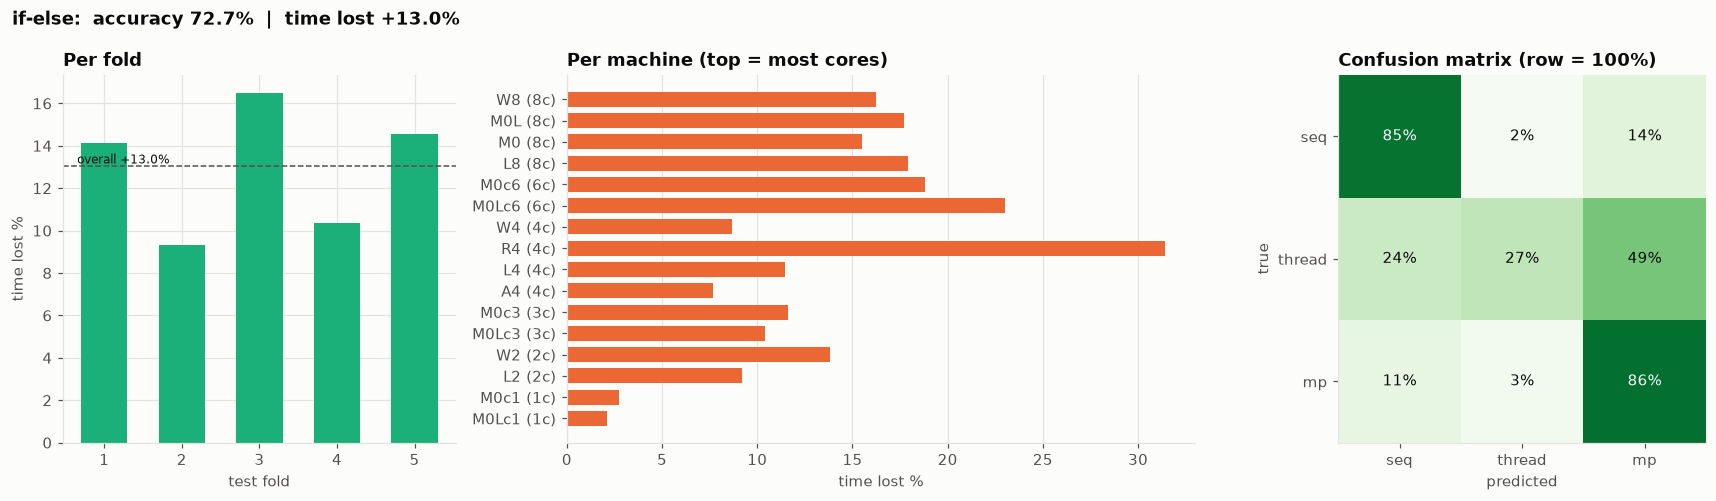

In [14]:
report("if-else")

In [15]:
th = pd.DataFrame([IfElseClassifier().fit(X.iloc[tr], y.iloc[tr]).thresholds_ for tr, _ in folds],
                  columns=["T_tiny (s/item)", "T_thread (speedup)", "T_pickle (ratio)"],
                  index=[f"fold {k}" for k in range(1, 6)])
th.round(5)

,T_tiny (s/item),T_thread (speedup),T_pickle (ratio)
fold 1,0.0,1.8,0.51553
fold 2,0.0,1.8,0.46663
fold 3,0.0,1.8,0.43888
fold 4,0.0,1.8,0.40468
fold 5,0.0,1.8,0.09809


- **+13.0%** ดีกว่า baseline แต่ threading ทายถูกแค่ราว 27%
- threshold เปลี่ยนตาม fold (`T_pickle` 0.10–0.52) แปลว่ากฎค่าเดียวใช้ได้ไม่ดีทุกเครื่องและทุกงาน
- คำตอบที่ถูกขึ้นกับหลาย feature พร้อมกัน ซึ่งกฎ if-else จับได้ยาก

---
## 6. Random Forest

tree หลายร้อยต้นโหวตกัน แต่ละต้นคือ if-else ที่คอมพิวเตอร์เขียนเอง และแตกกิ่งตามเงื่อนไขได้ (เช่น ถ้า core เยอะ ให้ใช้ threshold pickle อีกค่าหนึ่ง) ใช้ `class_weight="balanced"` และไม่ต้อง scale feature

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=0)
evaluate(rf, "RF (default)")

model          RF (default)
accuracy           0.857384
macro F1           0.846944
time lost %        5.763053
dtype: object

จูน `max_depth`, `min_samples_leaf` ด้วย nested CV (inner fold ตาม template):

In [18]:
from sklearn.model_selection import GridSearchCV

def neg_time_lost(estimator, X_val, y_val):
    """Scorer for GridSearchCV: higher is better, so return minus time lost."""
    return -time_lost(df.loc[X_val.index, TIME_COLS].to_numpy(), estimator.predict(X_val))


class GroupTuned(BaseEstimator, ClassifierMixin):
    """Grid search on inner folds split by template, inside each outer train fold."""

    def __init__(self, estimator, param_grid):
        self.estimator = estimator
        self.param_grid = param_grid

    def fit(self, X, y):
        inner = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=1)
        self.search_ = GridSearchCV(self.estimator, self.param_grid, cv=inner, scoring=neg_time_lost)
        self.search_.fit(X, y, groups=groups.loc[X.index])
        self.classes_ = self.search_.classes_
        return self

    def predict(self, X):
        return self.search_.predict(X)


rf_grid = {"max_depth": [8, 16, None], "min_samples_leaf": [1, 5, 20]}
rf_tuned = GroupTuned(RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                             n_jobs=-1, random_state=0), rf_grid)
evaluate(rf_tuned, "RF (tuned)")

model          RF (tuned)
accuracy         0.855032
macro F1         0.845465
time lost %      6.083254
dtype: object

In [19]:
chosen = []
for k, m in enumerate(results["RF (tuned)"]["models"], 1):     # reuse the models from evaluate(), no retraining
    chosen.append({"fold": k, **m.search_.best_params_, "validation time lost %": -m.search_.best_score_})
chosen = pd.DataFrame(chosen).set_index("fold")
chosen.round(2)

,max_depth,min_samples_leaf,validation time lost %
fold,,,
1,NaN,1,5.15
2,NaN,1,5.10
3,16.0,1,4.79
4,NaN,5,8.29
5,8.0,1,5.10


feature ที่ RF ใช้มากที่สุด (เทรนบน data ทั้งหมด ใช้ดูภาพรวมเท่านั้น):

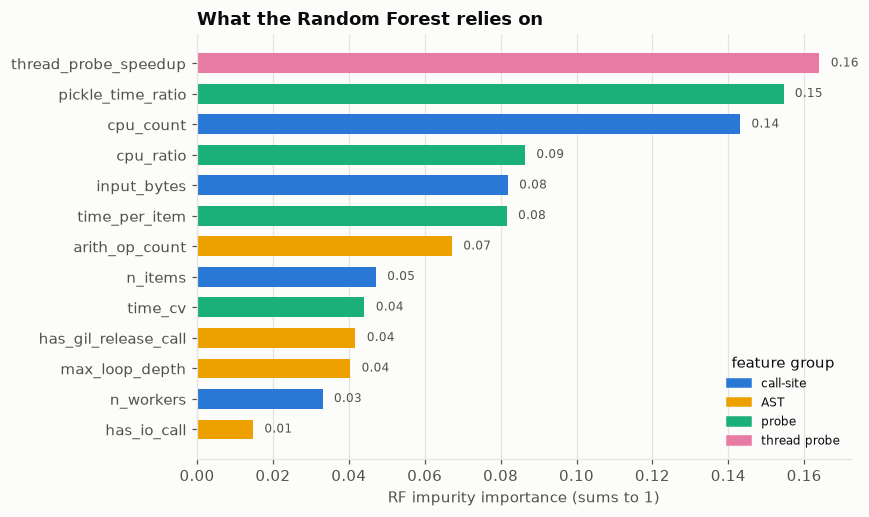

In [21]:
most_common = chosen[["max_depth", "min_samples_leaf"]].fillna(-1).mode().iloc[0]   # -1 stands for None
best_params = {k: (None if v == -1 else int(v)) for k, v in most_common.items()}
rf_all = RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=0,
                                **best_params).fit(X, y)
imp = pd.Series(rf_all.feature_importances_, FEATURE_NAMES).sort_values()
group = {f: g for g, fs in {"call-site": FEATURE_NAMES[0:4], "AST": FEATURE_NAMES[4:8],
                            "probe": FEATURE_NAMES[8:12], "thread probe": FEATURE_NAMES[12:]}.items() for f in fs}
gcolor = {"call-site": "#2a78d6", "AST": "#eda100", "probe": "#1baf7a", "thread probe": "#e87ba4"}

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(imp.index, imp.values, color=[gcolor[group[f]] for f in imp.index], height=0.65)
for i, v in enumerate(imp.values):
    ax.text(v + 0.003, i, f"{v:.2f}", va="center", fontsize=8, color="#52514e")
ax.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in gcolor.values()], gcolor.keys(),
          frameon=False, loc="lower right", title="feature group", fontsize=8)
ax.grid(axis="y", visible=False)
ax.set_xlabel("RF impurity importance (sums to 1)")
ax.set_title("What the Random Forest relies on")
save(fig, "03_rf_importance")
plt.show()

- **+5.8%** เสียเวลาน้อยกว่า if-else 2.2 เท่า threading ทายถูก 79% (if-else 27%)
- การจูนไม่ช่วย (+6.1%) เพราะส่วนใหญ่เลือกค่าเริ่มต้นอยู่แล้ว
- feature หลักชุดเดียวกับกฎ if-else แต่ RF ใช้มันร่วมกันแบบมีเงื่อนไข

---
## 7. MLP (Keras)

```
13 feature -> Dense+ReLU -> Dropout -> Dense+ReLU -> Dropout -> Dense 3 + softmax
```
- log + StandardScaler (fit บน train เท่านั้น) เพราะ feature มีขนาดต่างกันมาก
- กัน overfit ด้วย dropout, early stopping (validation = template 20%) และ L2 ส่วน optimizer ใช้ Adam

In [23]:
import os
os.environ["KERAS_BACKEND"] = "jax"          # same code as tf.keras; JAX does the math (TensorFlow has no Python 3.14 build)
import inspect
import keras
from sklearn.preprocessing import StandardScaler
from helpers import log_transform
from mlp_tuning import KerasMLP              # one shared copy: this notebook and the Optuna script use the same class

print("keras", keras.__version__, "| backend:", keras.backend.backend())
print(inspect.getsource(KerasMLP._build))    # the network definition, for reading

evaluate(KerasMLP(), "MLP (untuned)")

keras 3.15.1 | backend: jax
    def _build(self):
        reg = keras.regularizers.l2(self.l2) if self.l2 > 0 else None
        model = keras.Sequential([keras.Input(shape=(len(FEATURE_NAMES),))])
        for i in range(self.layers):
            model.add(keras.layers.Dense(max(self.units // (2 ** i), 8), activation="relu",
                                         kernel_regularizer=reg))       # 64 -> 32 -> 16 ...
            model.add(keras.layers.Dropout(self.dropout))
        model.add(keras.layers.Dense(len(MODES), activation="softmax"))
        model.compile(optimizer=keras.optimizers.Adam(self.learning_rate),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return model



model          MLP (untuned)
accuracy             0.84349
macro F1            0.831675
time lost %         5.234822
dtype: object

### Loss landscape

การเทรนคือการเดินลงเขาตาม gradient น้ำหนัก 3,075 มิติถูกฉายลง 2 ทิศหลักด้วย PCA (Li et al., NeurIPS 2018) แล้วคำนวณ loss จริงบนระนาบนั้น

In [26]:
# 1) train a fresh MLP on fold 1 and record the weights after every epoch = the path gradient descent walked
class RecordWeights(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.path = [self._flat()]
    def on_epoch_end(self, epoch, logs=None):
        self.path.append(self._flat())
    def _flat(self):
        return np.concatenate([w.ravel() for w in self.model.get_weights()])

tr, _ = folds[0]
Xtr, ytr = X.iloc[tr], y.iloc[tr]
y_int = ytr.map({m: i for i, m in enumerate(MODES)}).to_numpy().astype("int32")
scaler = StandardScaler().fit(log_transform(Xtr))
Z = scaler.transform(log_transform(Xtr))

keras.utils.set_random_seed(0)
net = KerasMLP()._build()
rec = RecordWeights()
net.fit(Z, y_int, epochs=60, batch_size=256, verbose=0, callbacks=[rec])
path = np.array(rec.path)                         # (61 epochs, n_weights)
shapes = [w.shape for w in net.get_weights()]
w_end = path[-1]
print(f"{path.shape[1]:,} weights, {len(path) - 1} epochs recorded")

# 2) the network has thousands of weights -> pick the 2 directions the path moved along most (PCA)
from sklearn.decomposition import PCA
pca = PCA(n_components=2).fit(path - w_end)
d1, d2 = pca.components_
coords = (path - w_end) @ np.stack([d1, d2]).T      # path position in the 2-D slice
print(f"these 2 directions explain {pca.explained_variance_ratio_.sum():.0%} of the movement")

# 3) loss on a grid around the final weights (same rows, no dropout, no class weights)
sub = np.random.default_rng(0).choice(len(Z), 3000, replace=False)
def unflatten(v):
    out, i = [], 0
    for s in shapes:
        n = int(np.prod(s)); out.append(v[i:i + n].reshape(s)); i += n
    return out

pad = 0.45
a = np.linspace(coords[:, 0].min() - pad * np.ptp(coords[:, 0]), coords[:, 0].max() + pad * np.ptp(coords[:, 0]), 35)
b = np.linspace(coords[:, 1].min() - pad * np.ptp(coords[:, 1]), coords[:, 1].max() + pad * np.ptp(coords[:, 1]), 35)
A, B = np.meshgrid(a, b)
L = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        net.set_weights(unflatten(w_end + A[i, j] * d1 + B[i, j] * d2))
        L[i, j] = net.evaluate(Z[sub], y_int[sub], batch_size=3000, verbose=0)[0]
def loss_at(v):
    net.set_weights(unflatten(v))
    return net.evaluate(Z[sub], y_int[sub], batch_size=3000, verbose=0)[0]

# height of the path = loss at its position in the 2-D slice, so the line sits on the surface
path_loss = np.array([loss_at(w_end + c1 * d1 + c2 * d2) for c1, c2 in coords])
true_loss = np.array([loss_at(v) for v in path])          # loss with all weights (not only the 2 directions)
print(f"real loss: start {true_loss[0]:.2f} -> end {true_loss[-1]:.2f}")

3,075 weights, 60 epochs recorded
these 2 directions explain 96% of the movement


real loss: start 1.09 -> end 0.28


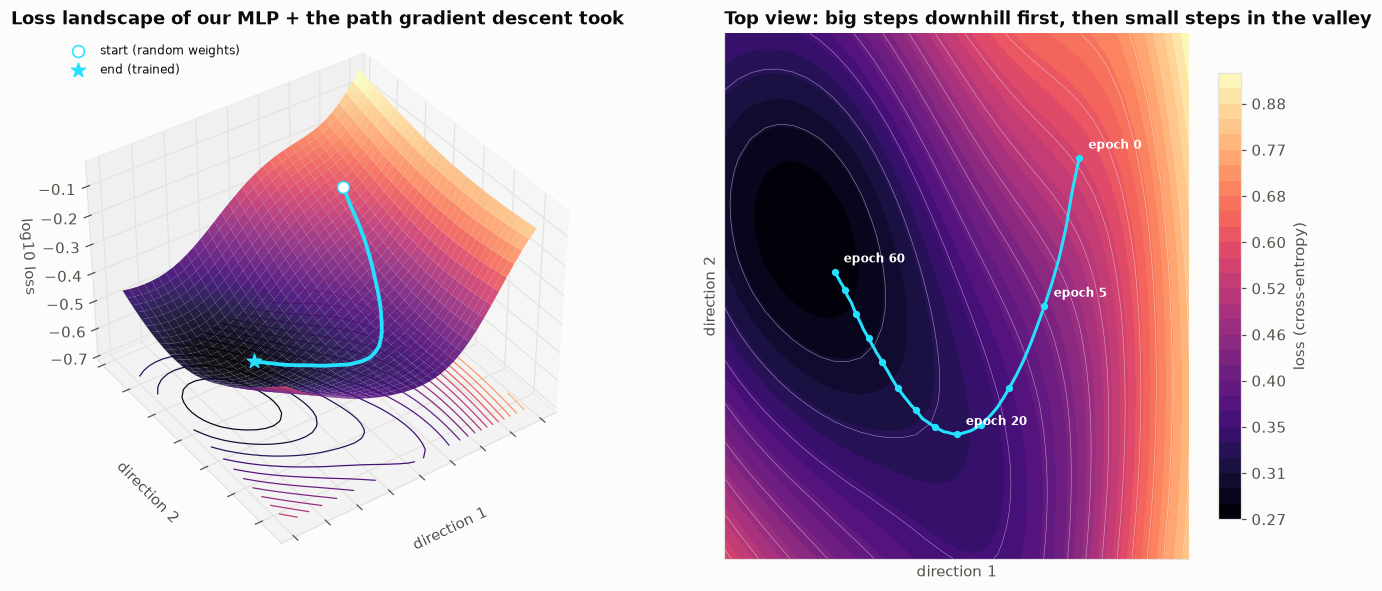

In [27]:
from matplotlib import cm
from matplotlib.colors import LogNorm

fig = plt.figure(figsize=(15, 6.2))
ax3 = fig.add_subplot(1, 2, 1, projection="3d", computed_zorder=False)   # keep the path drawn on top
logL = np.log10(L)
ax3.plot_surface(A, B, logL, zorder=1, cmap="magma", linewidth=0, antialiased=True, alpha=0.92,
                 rstride=1, cstride=1)
ax3.contour(A, B, logL, levels=18, zdir="z", offset=logL.min() - 0.15, cmap="magma", linewidths=0.8, zorder=0)
lift = 0.01
ax3.plot(coords[:, 0], coords[:, 1], np.log10(path_loss) + lift, color="#25e0ff", lw=2.5, zorder=10)
ax3.scatter(coords[0, 0], coords[0, 1], np.log10(path_loss[0]) + lift, color="white", s=60,
            edgecolor="#25e0ff", zorder=11, label="start (random weights)")
ax3.scatter(coords[-1, 0], coords[-1, 1], np.log10(path_loss[-1]) + lift, color="#25e0ff", s=90,
            marker="*", zorder=11, label="end (trained)")
ax3.set_zlim(logL.min() - 0.15, logL.max())
ax3.set_xlabel("direction 1"); ax3.set_ylabel("direction 2"); ax3.set_zlabel("log10 loss")
ax3.set_xticklabels([]); ax3.set_yticklabels([])
ax3.view_init(elev=38, azim=-125)
ax3.set_facecolor("#fcfcfb")
ax3.set_title("Loss landscape of our MLP + the path gradient descent took")
ax3.legend(loc="upper left", fontsize=8, frameon=False)

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contourf(A, B, L, levels=np.logspace(np.log10(L.min()), np.log10(L.max()), 30),
                  cmap="magma", norm=LogNorm())
ax2.contour(A, B, L, levels=np.logspace(np.log10(L.min()), np.log10(L.max()), 15),
            colors="white", linewidths=0.4, alpha=0.5)
ax2.plot(coords[:, 0], coords[:, 1], color="#25e0ff", lw=2)
ax2.scatter(coords[::5, 0], coords[::5, 1], color="#25e0ff", s=14, zorder=3)
for e in [0, 5, 20, len(coords) - 1]:
    ax2.annotate(f"epoch {e}", coords[e], xytext=(6, 6), textcoords="offset points",
                 color="white", fontsize=8, fontweight="bold")
ax2.set_xticks([]); ax2.set_yticks([]); ax2.grid(False)
ax2.set_xlabel("direction 1"); ax2.set_ylabel("direction 2")
ax2.set_title("Top view: big steps downhill first, then small steps in the valley")
fig.colorbar(cs, ax=ax2, shrink=0.85, label="loss (cross-entropy)", format="%.2f")
save(fig, "03_loss_landscape")
plt.show()

ช่วงแรกก้าวยาวและลงชัน พอถึงก้นหุบ ก้าวก็สั้นลง

**learning rate 3 ค่า** เริ่มจากน้ำหนักเดียวกัน:

In [29]:
# same network, same starting weights, 3 learning rates -> 3 paths on ONE shared landscape
from sklearn.decomposition import PCA

LRS = {"too small (0.00003)": 3e-5, "good (0.003)": 3e-3, "too big (0.1)": 0.1}
LR_COLORS = {"too small (0.00003)": "#86b6ef", "good (0.003)": "#25e0ff", "too big (0.1)": "#ff5c8a"}
EPOCHS = 40

keras.utils.set_random_seed(1)
init_net = KerasMLP()._build()
w0 = init_net.get_weights()                       # identical start for all three
paths = {}
for name, lr in LRS.items():
    net = KerasMLP()._build()
    net.set_weights(w0)
    net.compile(optimizer=keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy")
    rec = RecordWeights()
    keras.utils.set_random_seed(2)                # same batch order too
    net.fit(Z, y_int, epochs=EPOCHS, batch_size=256, verbose=0, callbacks=[rec])
    paths[name] = np.array(rec.path)

# plane = the 2 main directions of the GOOD path (where the real valley is); the other paths are projected onto it
center = paths["good (0.003)"][-1]
pca_lr = PCA(n_components=2).fit(paths["good (0.003)"] - center)
e1, e2 = pca_lr.components_
proj = {n: (p - center) @ np.stack([e1, e2]).T for n, p in paths.items()}

# zoom on the valley around the good + small paths; the big-lr path is allowed to leave the frame
pts = np.vstack([proj["good (0.003)"], proj["too small (0.00003)"]])
lo, hi = pts.min(axis=0), pts.max(axis=0)
span = hi - lo
ga = np.linspace(lo[0] - 0.6 * span[0], hi[0] + 0.6 * span[0], 41)
gb = np.linspace(lo[1] - 0.6 * span[1], hi[1] + 0.6 * span[1], 41)
inside = {n: (pr[:, 0] >= ga[0]) & (pr[:, 0] <= ga[-1]) & (pr[:, 1] >= gb[0]) & (pr[:, 1] <= gb[-1])
          for n, pr in proj.items()}
for n in proj:
    print(f"{n:22s} epochs inside the zoomed valley: {inside[n].sum()} / {len(inside[n])}")
GA, GB = np.meshgrid(ga, gb)
probe = KerasMLP()._build()
def loss_on_plane(c1, c2):
    probe.set_weights(unflatten(center + c1 * e1 + c2 * e2))
    return probe.evaluate(Z[sub], y_int[sub], batch_size=3000, verbose=0)[0]
GL = np.array([[loss_on_plane(GA[i, j], GB[i, j]) for j in range(GA.shape[1])] for i in range(GA.shape[0])])
plane_loss = {n: np.array([loss_on_plane(c1, c2) for c1, c2 in pr]) for n, pr in proj.items()}
for n, p in paths.items():
    print(f"{n:22s} loss on the plane: start {plane_loss[n][0]:.2f} -> end {plane_loss[n][-1]:.2f}")

too small (0.00003)    epochs inside the zoomed valley: 41 / 41
good (0.003)           epochs inside the zoomed valley: 41 / 41
too big (0.1)          epochs inside the zoomed valley: 30 / 41


too small (0.00003)    loss on the plane: start 0.49 -> end 0.46
good (0.003)           loss on the plane: start 0.49 -> end 0.26
too big (0.1)          loss on the plane: start 0.49 -> end 0.41


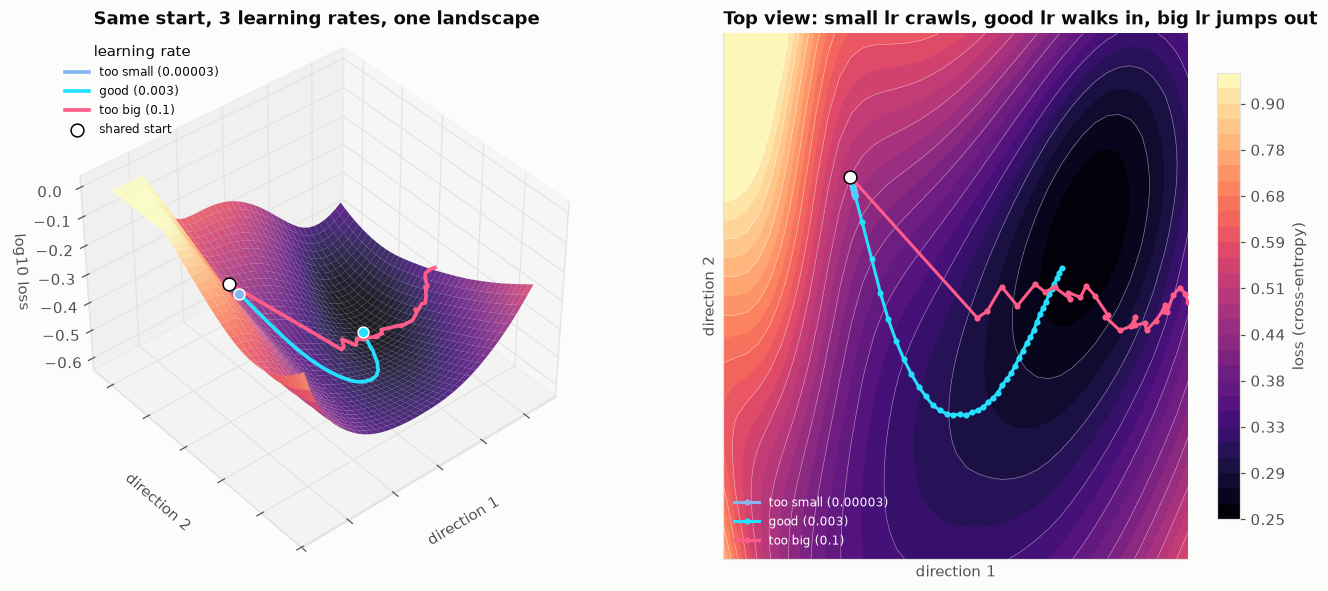

In [30]:
fig = plt.figure(figsize=(15, 6.2))
ax3 = fig.add_subplot(1, 2, 1, projection="3d", computed_zorder=False)
GLc = np.log10(np.clip(GL, None, np.quantile(GL, 0.97)))     # cap the very top so the valley stays visible
ax3.plot_surface(GA, GB, GLc, cmap="magma", linewidth=0, alpha=0.88, rstride=1, cstride=1, zorder=1)
for n, pr in proj.items():
    z = np.log10(np.clip(plane_loss[n], None, np.quantile(GL, 0.97))) + 0.01
    m = np.where(inside[n], 1.0, np.nan)                 # hide the parts that left the zoomed area
    ax3.plot(pr[:, 0] * m, pr[:, 1] * m, z * m, color=LR_COLORS[n], lw=2.4, zorder=5, label=n)
    if inside[n][-1]:
        ax3.scatter(pr[-1, 0], pr[-1, 1], z[-1], color=LR_COLORS[n], s=50, edgecolor="white", zorder=6)
start = list(proj.values())[0][0]
ax3.scatter(start[0], start[1], np.log10(min(plane_loss[n][0], np.quantile(GL, 0.97))) + 0.01,
            color="white", edgecolor="black", s=70, zorder=7, label="shared start")
ax3.set_xticklabels([]); ax3.set_yticklabels([])
ax3.set_xlabel("direction 1"); ax3.set_ylabel("direction 2"); ax3.set_zlabel("log10 loss")
ax3.view_init(elev=40, azim=-130)
ax3.legend(loc="upper left", fontsize=8, frameon=False, title="learning rate")
ax3.set_title("Same start, 3 learning rates, one landscape")

ax2 = fig.add_subplot(1, 2, 2)
levels = np.logspace(np.log10(GL.min()), np.log10(np.quantile(GL, 0.97)), 30)
cs = ax2.contourf(GA, GB, np.clip(GL, None, levels[-1]), levels=levels, cmap="magma", norm=LogNorm())
ax2.contour(GA, GB, np.clip(GL, None, levels[-1]), levels=levels[::2], colors="white", linewidths=0.4, alpha=0.5)
for n, pr in proj.items():
    ax2.plot(pr[:, 0], pr[:, 1], color=LR_COLORS[n], lw=2, marker="o", ms=3, label=n)
ax2.set_xlim(ga[0], ga[-1]); ax2.set_ylim(gb[0], gb[-1])        # big-lr path runs off the edge
ax2.scatter(start[0], start[1], color="white", edgecolor="black", s=70, zorder=5)
ax2.set_xticks([]); ax2.set_yticks([]); ax2.grid(False)
ax2.set_xlabel("direction 1"); ax2.set_ylabel("direction 2")
ax2.legend(frameon=False, fontsize=8, labelcolor="white", loc="lower left")
ax2.set_title("Top view: small lr crawls, good lr walks in, big lr jumps out")
fig.colorbar(cs, ax=ax2, shrink=0.85, label="loss (cross-entropy)", format="%.2f")
save(fig, "03_learning_rates_landscape")
plt.show()


เล็กเกินไปจะแทบไม่ขยับ ใหญ่เกินไปจะกระโดดข้ามหุบ ค่าที่พอดีลงถึงก้นหุบ learning rate จึงเป็นค่าหนึ่งที่ให้ Optuna จูน

MLP ค่าตั้งต้นได้ **+5.2%** สูสีกับ RF

### จูนด้วย Optuna

5 outer fold × 50 trial (TPE + MedianPruner) จูน 6 ค่า: ชั้น, neuron, dropout, learning rate, batch size, L2 แต่ละ fold จูนด้วย train ของตัวเอง แล้ววัดผลบน test ของ fold นั้น

In [33]:
import optuna
import optuna.visualization.matplotlib as ov
from mlp_tuning import OPTUNA_DB, FOLDS as TUNE_FOLDS

assert all((a[1] == b[1]).all() for a, b in zip(folds, TUNE_FOLDS))   # the script used exactly these folds
optuna.logging.set_verbosity(optuna.logging.WARNING)
studies = [optuna.load_study(study_name=f"mlp_fold{k}", storage=OPTUNA_DB) for k in range(1, 6)]

best_table = pd.DataFrame([{"fold": k, "val time lost %": s.best_value, **s.best_params,
                            "complete": sum(t.state.name == "COMPLETE" for t in s.trials),
                            "pruned": sum(t.state.name == "PRUNED" for t in s.trials)}
                           for k, s in enumerate(studies, 1)]).set_index("fold")
best_table.round(4)

,val time lost %,layers,units,dropout,learning_rate,batch_size,l2,complete,pruned
fold,,,,,,,,,
1,1.2745,3,115,0.3014,0.0012,512,0.0072,21,29
2,3.3547,1,188,0.2526,0.0006,64,0.0062,28,22
3,1.8598,1,225,0.0715,0.0035,128,0.0000,46,4
4,1.4879,4,234,0.0087,0.0011,128,0.0000,38,12
5,1.0934,1,227,0.3777,0.0075,128,0.0001,34,16


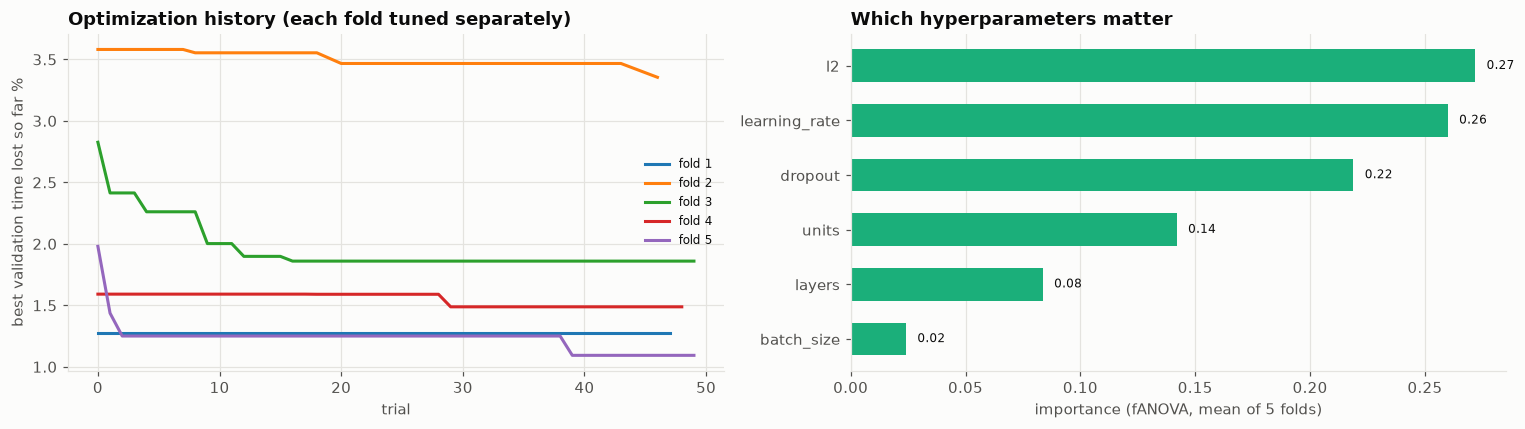

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for k, s in enumerate(studies, 1):
    done_t = [t for t in s.trials if t.state.name == "COMPLETE"]     # pruned trials store val_loss, not time lost
    vals = [t.value for t in done_t]
    nums = [t.number for t in done_t]
    axes[0].plot(nums, np.minimum.accumulate(vals), lw=2, label=f"fold {k}")
axes[0].set_xlabel("trial"); axes[0].set_ylabel("best validation time lost so far %")
axes[0].set_title("Optimization history (each fold tuned separately)")
axes[0].legend(frameon=False, fontsize=8)

imp = pd.DataFrame([optuna.importance.get_param_importances(s) for s in studies]).mean().sort_values()
axes[1].barh(imp.index, imp.values, color="#1baf7a", height=0.6)
for i, v in enumerate(imp.values):
    axes[1].text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=8)
axes[1].grid(axis="y", visible=False)
axes[1].set_xlabel("importance (fANOVA, mean of 5 folds)")
axes[1].set_title("Which hyperparameters matter")
save(fig, "03_optuna_history_importance")
plt.show()

In [36]:
class OptunaMLP(BaseEstimator, ClassifierMixin):
    """Uses the best Optuna params found on THIS outer fold's train rows."""

    def fit(self, X, y):
        k = next(i for i, (tr, _) in enumerate(folds) if len(tr) == len(X) and (df.index[tr] == X.index).all())
        self.params_ = studies[k].best_params
        self.mlp_ = KerasMLP(**self.params_).fit(X, y)
        self.classes_ = self.mlp_.classes_
        return self

    def predict(self, X):
        return self.mlp_.predict(X)

evaluate(OptunaMLP(), "MLP (Optuna)")

model          MLP (Optuna)
accuracy            0.84452
macro F1           0.830694
time lost %        4.276711
dtype: object

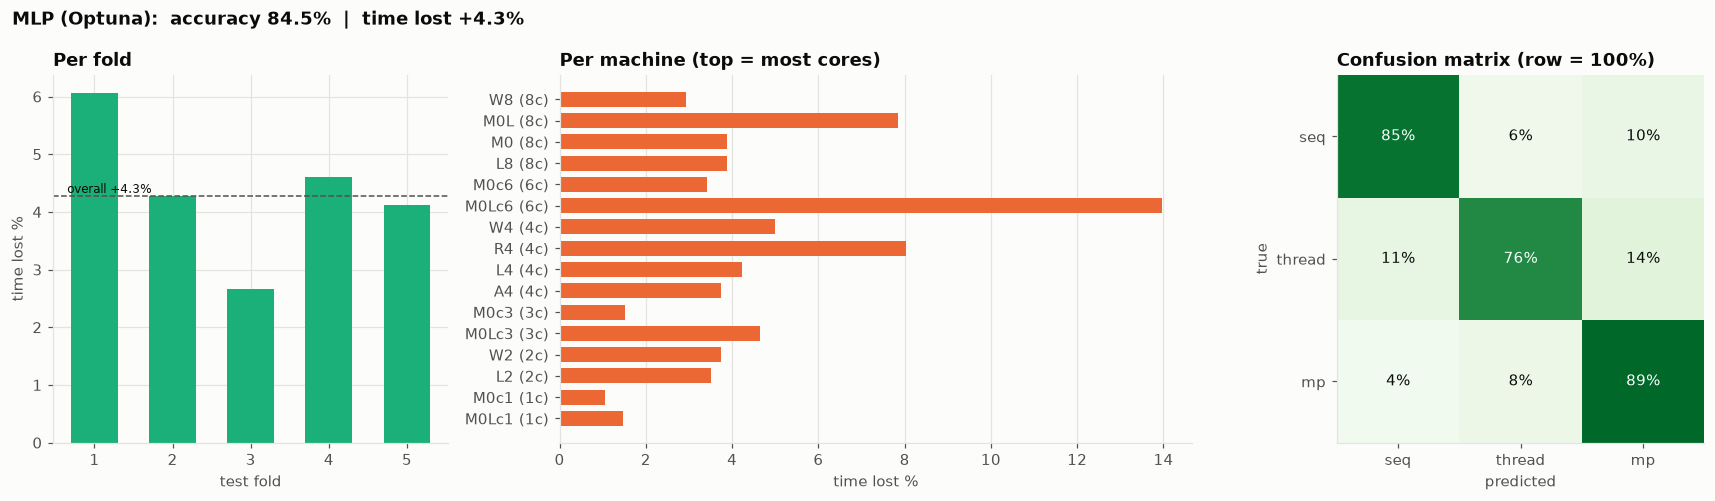

In [37]:
report("MLP (Optuna)")

- **+4.3%** ดีที่สุดในทุกโมเดล
- validation ได้ 1–3% แต่ test ได้ 4.3% เพราะการเลือกตัวที่ดีที่สุดจาก 50 trial ย่อมเข้าข้าง validation นี่คือเหตุผลที่ต้องเก็บ test แยกไว้นอกการจูน
- hyperparameter ที่มีผลมาก: L2, learning rate, dropout

---
## 8. Stress test

MLP ใช้ค่ากลางของ Optuna จาก 5 fold ทดสอบ 3 แบบ: สุ่มแบ่งแถว (วิธีที่ผิด), เครื่องที่ไม่เคยเห็น และงานประเภทที่ไม่เคยเห็น

In [39]:
from sklearn.model_selection import KFold, LeaveOneGroupOut

def final_mlp_params():
    bp = pd.DataFrame([s.best_params for s in studies])
    return {"layers": int(bp.layers.median()), "units": int(bp.units.median()),
            "dropout": float(bp.dropout.median()), "learning_rate": float(np.exp(np.log(bp.learning_rate).median())),
            "batch_size": int(bp.batch_size.mode()[0]), "l2": float(np.exp(np.log(bp.l2).median()))}

FINAL_MLP = final_mlp_params()
print("final MLP params:", FINAL_MLP)

contenders = {"always mp": DummyClassifier(strategy="constant", constant="multiprocessing"),
              "if-else": IfElseClassifier(),
              "RF": RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=0),
              "MLP": KerasMLP(**FINAL_MLP)}

def cv_score(model, splits):
    pred = np.empty(len(y), dtype=object)
    for tr, te in splits:
        pred[te] = clone(model).fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])
    return time_lost(times, pred), (pred == y).mean(), pred

split_sets = {
    "random rows (wrong)": list(KFold(5, shuffle=True, random_state=0).split(X)),
    "by template (main)": folds,
    "unseen machine": list(LeaveOneGroupOut().split(X, y, df.machine_group)),
    "unseen family": list(LeaveOneGroupOut().split(X, y, df.family)),
}
stress, stress_pred = {}, {}
for sname, splits in split_sets.items():
    for mname, model in contenders.items():
        lost, acc, pred = cv_score(model, splits)
        stress[(sname, mname)] = {"time lost %": lost, "accuracy": acc}
        stress_pred[(sname, mname)] = pred
stress_df = pd.DataFrame(stress).T
stress_df["time lost %"].unstack().loc[list(split_sets)][list(contenders)].round(1)

final MLP params: {'layers': 1, 'units': 225, 'dropout': 0.25263430043107105, 'learning_rate': 0.001229607110732572, 'batch_size': 128, 'l2': 0.00010626816336571304}


,always mp,if-else,RF,MLP
random rows (wrong),22.1,10.7,3.3,5.4
by template (main),22.1,13.0,5.8,4.5
unseen machine,22.1,10.7,7.7,5.7
unseen family,22.1,15.6,6.0,4.4


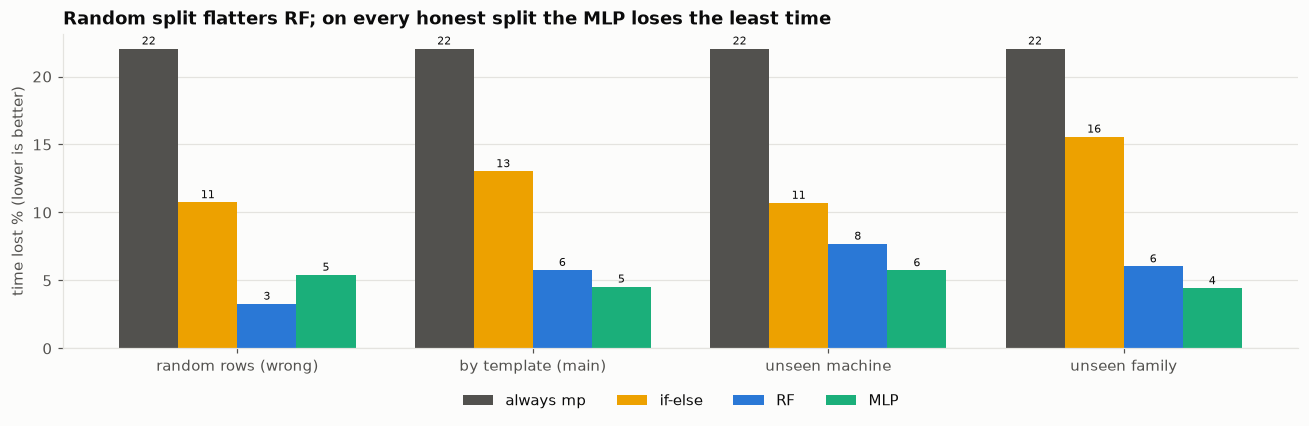

In [40]:
tab = stress_df["time lost %"].unstack().loc[list(split_sets)][list(contenders)]
colors = {"always mp": "#52514e", "if-else": "#eda100", "RF": "#2a78d6", "MLP": "#1baf7a"}
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(tab))
w = 0.2
for k, m in enumerate(tab.columns):
    bars = ax.bar(x + (k - 1.5) * w, tab[m], width=w, color=colors[m], label=m)
    for b, v in zip(bars, tab[m]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.3, f"{v:.0f}", ha="center", fontsize=7)
ax.set_xticks(x, tab.index)
ax.set_ylabel("time lost % (lower is better)")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.1))
ax.set_title("Random split flatters RF; on every honest split the MLP loses the least time")
save(fig, "03_stress_tests")
plt.show()


- สุ่มแบ่งแถวทำให้ RF ดูดีเกินจริง (3.3%) เพราะ RF จำ template ได้
- เครื่องใหม่: MLP 5.7%, RF 7.7%, if-else 10.7% และงานแบบใหม่: MLP 4.4%, RF 6.0%, if-else 15.6%
- ในทุกการทดสอบที่แบ่ง data ถูกต้อง MLP เสียเวลาน้อยที่สุด

**overfit:** time lost บน train เทียบกับ test

In [41]:
gap = []
for mname in ["RF", "MLP"]:
    for k, (tr, te) in enumerate(folds, 1):
        m = clone(contenders[mname]).fit(X.iloc[tr], y.iloc[tr])
        gap.append({"model": mname, "fold": k,
                    "train": time_lost(times[tr], m.predict(X.iloc[tr])),
                    "test": time_lost(times[te], m.predict(X.iloc[te]))})
gap = pd.DataFrame(gap)

gap.groupby("model")[["train", "test"]].mean().round(2)

,train,test
model,,
MLP,3.08,4.68
RF,0.25,5.51


RF จำ train ได้เกือบหมด (0.25% เทียบกับ 5.5%) ส่วน MLP มีช่องว่างแคบ (3.1% เทียบกับ 4.7%) จึงไม่ overfit

**ความนิ่ง:** เทรนใหม่ด้วย 3 seed

In [42]:
seed_runs = {s: cv_score(KerasMLP(**FINAL_MLP, seed=s), folds)[0] for s in [0, 1, 2]}
rf_runs = {s: cv_score(RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=s), folds)[0]
           for s in [0, 1, 2]}
print("MLP time lost by seed:", {k: round(float(v), 2) for k, v in seed_runs.items()},
      f"-> {np.mean(list(seed_runs.values())):.2f} ± {np.std(list(seed_runs.values())):.2f}")
print("RF  time lost by seed:", {k: round(float(v), 2) for k, v in rf_runs.items()},
      f"-> {np.mean(list(rf_runs.values())):.2f} ± {np.std(list(rf_runs.values())):.2f}")

MLP time lost by seed: {0: 4.54, 1: 5.31, 2: 4.61} -> 4.82 ± 0.34
RF  time lost by seed: {0: 5.76, 1: 5.91, 2: 5.73} -> 5.80 ± 0.08


MLP 4.8% ± 0.3 และ RF 5.8% ± 0.1 MLP ดีกว่าทุก seed

---
## 9. สรุป

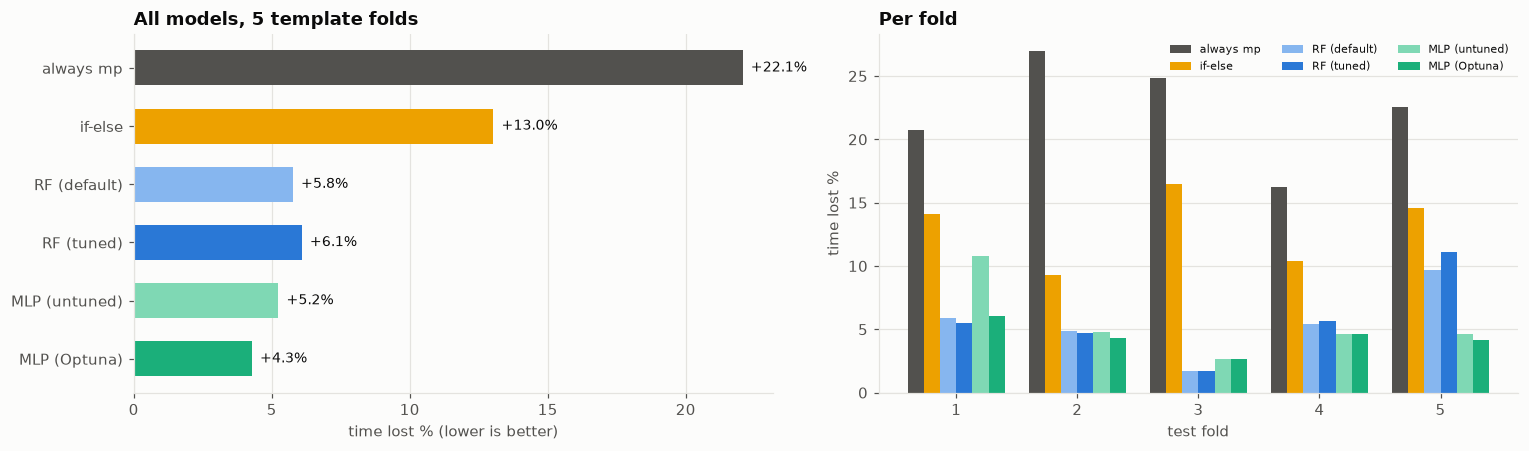

,accuracy,macro F1,time lost %
model,,,
always mp,0.447,0.206,22.057
if-else,0.727,0.657,13.025
RF (default),0.857,0.847,5.763
RF (tuned),0.855,0.845,6.083
MLP (untuned),0.843,0.832,5.235
MLP (Optuna),0.845,0.831,4.277


In [43]:
compare = pd.DataFrame([{k: v for k, v in r.items() if k not in ("pred", "per_fold", "run_id", "models")}
                        for r in results.values()]).set_index("model")
fold_lost = pd.DataFrame({n: r["per_fold"]["time lost %"].to_numpy() for n, r in results.items()}, index=range(1, 6))
palette = {"always mp": "#52514e", "if-else": "#eda100", "RF (default)": "#86b6ef", "RF (tuned)": "#2a78d6",
           "MLP (untuned)": "#7fd8b4", "MLP (Optuna)": "#1baf7a"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
names = list(compare.index)
axes[0].barh(names, compare["time lost %"], color=[palette[n] for n in names], height=0.6)
for i, v in enumerate(compare["time lost %"]):
    axes[0].text(v + 0.3, i, f"+{v:.1f}%", va="center", fontsize=9)
axes[0].invert_yaxis(); axes[0].grid(axis="y", visible=False)
axes[0].set_xlabel("time lost % (lower is better)"); axes[0].set_title("All models, 5 template folds")
w = 0.8 / len(names)
for k, n in enumerate(names):
    axes[1].bar(fold_lost.index + (k - (len(names) - 1) / 2) * w, fold_lost[n], width=w, color=palette[n], label=n)
axes[1].set_xlabel("test fold"); axes[1].set_ylabel("time lost %")
axes[1].legend(frameon=False, fontsize=7, ncol=3); axes[1].grid(axis="x", visible=False)
axes[1].set_title("Per fold")
save(fig, "03_all_models_final")
plt.show()
compare.round(3)

**เลือก MLP (Optuna)** เพราะเสียเวลาน้อยที่สุดในทุกการทดสอบ (4–6%) ลดเวลาที่เสียไปได้ราว 3 เท่าเมื่อเทียบกับ if-else (13%) และไม่ overfit

**ข้อจำกัด:** มีเครื่อง ARM แค่เครื่องเดียว, workload เป็นแบบสังเคราะห์ (ทดสอบกับโค้ดจริงจาก pyperformance แยกต่างหาก) และผลของ MLP แกว่ง ±0.3 ตาม seed